In [1]:
import pandas as pd
import os 
import numpy as np
import struct
from datetime import datetime, date, timedelta 
import tqdm as tqdm
import pickle

import matplotlib.pyplot as plt
import scipy as sp


In [2]:
def getdata(input_file):
    Lt = []
    Al = []
    Lat = []
    Long = []
    dfArray0 = []
    dfArray1 = []
    timel =[]
    RECL = 8510
    with open(input_file, 'rb') as f:
        piece = f.read(RECL)
    
        counter = 0  # count of the number of occurrences of RELC
        while piece:
            counter += 1
            datcds = [int.from_bytes(piece[:4], byteorder='big'), int.from_bytes(piece[4:8], byteorder='big')]
            day=np.mod(datcds[0],16777216)
            msec=datcds[1]
            record_date = date(1950, 1, 1) + timedelta(days=int(day))
            i = 8; delta = 2 * 7
            time = struct.unpack('>'+'h'*7, piece[i:i+delta])
            i = i + delta; delta = 2 * 2

            orb, sorb = struct.unpack('>hh', piece[i:i + delta])
            print(orb,sorb)

            i = i + delta; delta = 8

            tms = "".join([s.decode() for s in struct.unpack('>' +'s'*8, piece[i:i+delta])])

            i = i + delta; delta = 4
            soft_cal = struct.unpack('>bbbb', piece[i:i + delta])

            i = i + delta; delta = 4*4
            orbp = struct.unpack('>ffff', piece[i:i+delta])
            Geocentric_lat = f"{orbp[0]:.4f}"
            Geocentric_long = f"{orbp[1]:.4f}"
            local_time = f"{orbp[3]:.4f}"
            Altitude = f"{orbp[2]:.3f}"
            i += delta; delta = 4*15
            geop = struct.unpack('>'+'f'*15, piece[i:i+delta])


            i += delta; delta = 4*3
            solp = struct.unpack('>'+'f'*3, piece[i:i+delta])

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i += delta; delta = 4*18
            attp = struct.unpack('>'+'f'*18, piece[i:i+delta])

            i = i + delta; delta = 2
            qi = struct.unpack('>h', piece[i:i + delta])[0]

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i = i + delta; delta = 21
            type = "".join([s.decode() for s in struct.unpack('>' +'s'*21, piece[i:i+delta])])

            i = i + delta; delta = 32
            hk = struct.unpack('>'+'c'*32, piece[i:i + delta])
            HKs = "".join([el.hex() for el in hk])

            i = i + delta; delta = 9
            coord = "".join([s.decode() for s in struct.unpack('>' +'s'*9, piece[i:i+delta])])

            i = i + delta; delta = 3
            name = "".join([s.decode() for s in struct.unpack('>' +'s'*3, piece[i:i+delta])])

            i = i + delta; delta = 16
            unit = "".join([s.decode('latin-1') for s in struct.unpack('>' +'s'*16, piece[i:i+delta])])

            i = i + delta; delta = 1
            nbsp = struct.unpack('>'+'b'*1, piece[i:i + delta])[0]
            #print(f"Number of consecutice spectra = {nbsp}")
            i = i + delta; delta = 2
            nbf = struct.unpack('>h', piece[i:i + delta])[0]
            #print(f"Number of spectrum frequencies  = {nbf}")
            i += delta; delta = 4
            dt = struct.unpack('>f', piece[i:i+delta])[0]
            
            #print(f"Time duration of one data array = {dt:.4f}")
            i += delta; delta = 4
            freq = struct.unpack('>f', piece[i:i+delta])[0]
            Frequency_resolution = f"{freq:.4f}"
            #print(f"Frequency resolution = {freq:.4f}")
            i += delta; delta = 4*2
            frange = struct.unpack('>ff', piece[i:i+delta])[0]
            #print(f"Frequency range = {frange:.4f}")
            i += delta; delta = 2 * 7
            idatsp = struct.unpack('>'+'h'*7, piece[i:i+delta])
            #print(f"time = {idatsp}")
            i += delta
            sp = struct.unpack('>2048f', piece[i:])
            sp_0 = sp[:1024]
            sp_1 = sp[1024:]
            dfArray0.append(np.array(sp_0)) 
            dfArray1.append(np.array(sp_1)) 
            dt = datetime(year=int(time[0]), month=int(time[1]), day=int(time[2]), hour=int(time[3]),minute=int(time[4]), second=int(time[5]),microsecond=int(time[6])*1000)
            date_time = dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
            timel.append(date_time)
            Lt.append(local_time)
            Al.append(Altitude)
            Lat.append(Geocentric_lat)
            Long.append(Geocentric_long)
            #frq.append(Frequency_resolution)
           
            piece = f.read(RECL)
            OP = pd.DataFrame({'time':timel, 'Geocentric_lat':Lat, 'Geocentric_long':Long, 'Altitude': Al,"Local_time":Lt, 'spectrum0':dfArray0,'spectrum1':dfArray1}) 
            df = pd.concat([OP])
            df.columns=['datetime', 'geo_lat', 'geo_long', 'altitude', 'localtime', 'spectrum0','spectrum1']

    return df

                        

In [5]:

input_file ="D:\GIT\Demeter-Anomaly-Detection-Framework\Data\DMT_N1_1132_000420_20040705_080034_20040705_080559.DAT"


# input_file ="C:\PROJECT-DEMETER\Paper1\Data\DMT_N1_1132_000420_20040705_080034_20040705_080559.DAT"
data = getdata(input_file)

42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0
42 0


In [6]:
data

,datetime,geo_lat,geo_long,altitude,localtime,spectrum0,spectrum1
0,2004-07-05 08:00:33.830,-0.3017,33.0315,708.472,10.2115,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
1,2004-07-05 08:00:37.830,-0.5418,32.9799,708.455,10.2092,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
2,2004-07-05 08:00:41.830,-0.7820,32.9284,708.438,10.2068,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
3,2004-07-05 08:00:45.830,-1.0221,32.8768,708.421,10.2045,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
4,2004-07-05 08:00:49.830,-1.2623,32.8252,708.404,10.2022,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
...,...,...,...,...,...,...,...
63,2004-07-05 08:05:42.831,-18.8490,28.9431,709.095,10.0248,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
64,2004-07-05 08:05:46.831,-19.0889,28.8874,709.129,10.0222,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
65,2004-07-05 08:05:50.831,-19.3288,28.8317,709.163,10.0196,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."
66,2004-07-05 08:05:54.831,-19.5688,28.7759,709.197,10.0170,"[-11.236061096191406, -11.552206039428711, -11...","[-11.236061096191406, -11.552206039428711, -11..."


Lets see how the spectrum looks like

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\PROJECT-DEMETER\\Paper1\\plots\\fig_2a.png'

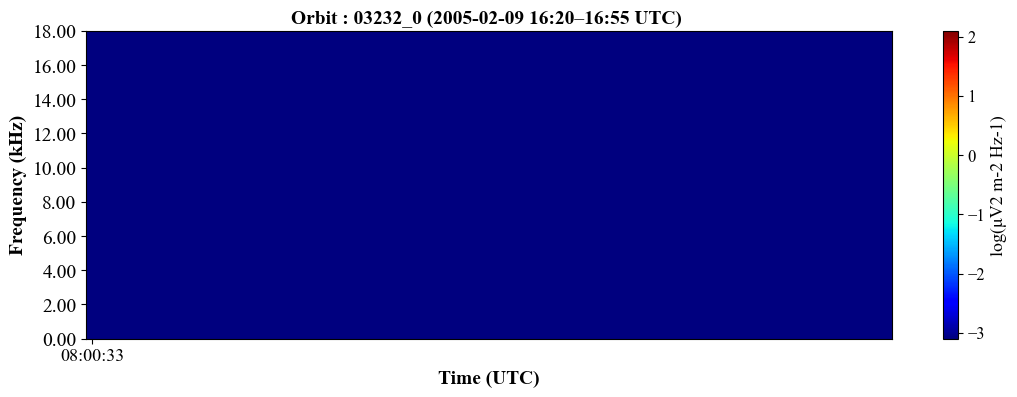

In [7]:

import numpy as  np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set Cambria as default font
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

rcParams['font.size'] = 12     # if you want all text size 12 by default

# data1 = pd.read_pickle('F:\\ASCII_1132\\28-02-2010.pkl')
sp_01 =data['spectrum1'].values
sp_01 = np.array([np.array(x) for x in sp_01])
sp_01 = sp_01.astype(float)
sp_0 =data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0])
sp_0 = sp_0.astype(float)



# min_freq = 19.035
# max_freq = 18000
#freq_list = np.logspace(np.log10(min_freq), np.log10(max_freq),sp_0.shape[0])
min_freq = 0
max_freq = 18
# Generate a list of frequencies using numpy
freq_list = np.linspace(min_freq, max_freq,10)
freq_list = ["%.2f" % z for z in freq_list]

fig, ax = plt.subplots(figsize=(13,4))
im = ax.imshow(sp_01.T, origin='lower', aspect='auto', cmap='jet',vmax= 2.1, vmin = -3.1)
im = ax.imshow(sp_0.T, origin='lower', aspect='auto', cmap='jet',vmax= 2.1, vmin = -3.1)
ax.set_yticks(np.linspace(0, 1024, 10),freq_list, fontsize =14)

# datetime1 = data['datetime']
# xticks1 = list(range(0, 513, 95))
# ax.set_xticks(xticks1, datetime1[xticks1],fontsize =12)
# Ensure it's a datetime series
datetime1 = pd.to_datetime(data['datetime'])

# Choose tick positions (same as you had)
xticks1 = list(range(0, len(datetime1), 95))

# Set ticks and use only HH:MM as labels
ax.set_xticks(xticks1)
ax.set_xticklabels(datetime1.dt.strftime('%H:%M:%S').iloc[xticks1], fontsize=13, rotation=0)

# ax.set_xlabel('Time (hh:mm)', fontsize=13)

# ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add colorbar
cbar = fig.colorbar(im)
cbar.set_label('log(μV2 m-2 Hz-1)', fontsize =13)
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
#ax.set_yticks(range(1024), )
# Set the axis labels
plt.title(f'Orbit : 03232_0 (2005-02-09 16:20–16:55 UTC) ', weight='bold',fontsize =14)
ax.set_xlabel('Time (UTC)', weight='bold',fontsize =14)
ax.set_ylabel('Frequency (kHz)',weight='bold', fontsize =14)
fig.savefig(
    r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.png",
    dpi=600,
    bbox_inches='tight',   # remove surrounding white margins
    pad_inches=0           # (optional) no extra padding at all
)
fig.set_size_inches(9.5, 3.5)  # width, height in inches

fig.savefig(
    r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.eps",
    dpi=600,
    bbox_inches="tight"
)

#print(sp_0,freq_index)
# Show the plot
plt.show()




sp_01.shape

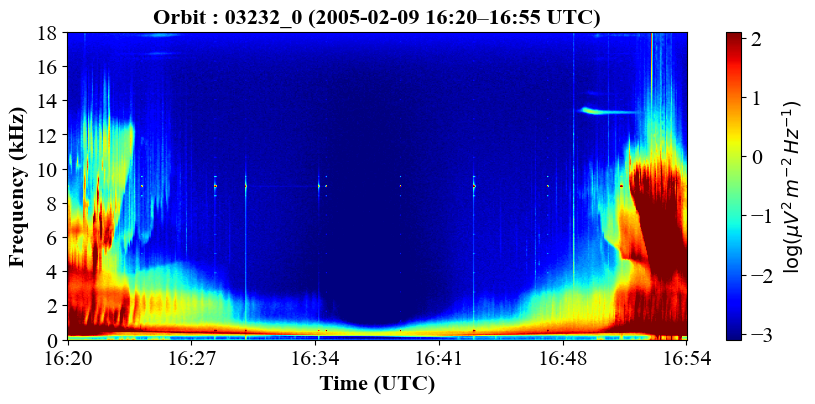

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FormatStrFormatter

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16

# Extract spectrum
sp_0 = data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0], dtype=float)

# Frequency labels
min_freq = 0
max_freq = 18
freq_list = np.linspace(min_freq, max_freq, 10)

fig, ax = plt.subplots(figsize=(10, 4))

# Plot only one spectrum
im = ax.imshow(
    sp_0.T,
    origin='lower',
    aspect='auto',
    cmap='jet',
    vmax=2.1,
    vmin=-3.1
)

# Y-axis ticks and labels without decimal points
yticks = np.linspace(0, sp_0.shape[1] - 1, 10)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y)}" for y in freq_list])

# Time axis
datetime1 = pd.to_datetime(data['datetime'])

# Choose tick positions
xticks1 = np.linspace(0, len(datetime1) - 1, 6, dtype=int)

# Format as HH:MM only
ax.set_xticks(xticks1)
ax.set_xticklabels(datetime1.dt.strftime('%H:%M').iloc[xticks1], rotation=0)

# Labels and title
ax.set_title('Orbit : 03232_0 (2005-02-09 16:20–16:55 UTC)', weight='bold')
ax.set_xlabel('Time (UTC)', weight='bold')
ax.set_ylabel('Frequency (kHz)', weight='bold')

# Colorbar
cbar = fig.colorbar(im)
cbar.set_label(r'$\log(\mu V^2\, m^{-2}\, Hz^{-1})$', fontsize=14)
cbar.ax.tick_params()

# Standardize tick font sizes
ax.tick_params(axis='both')

# Save
fig.savefig(
    r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.png",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0
)

fig.savefig(
    r"C:\PROJECT-DEMETER\Paper1\plots\fig_2a.eps",
    dpi=600,
    bbox_inches='tight'
)

plt.show()